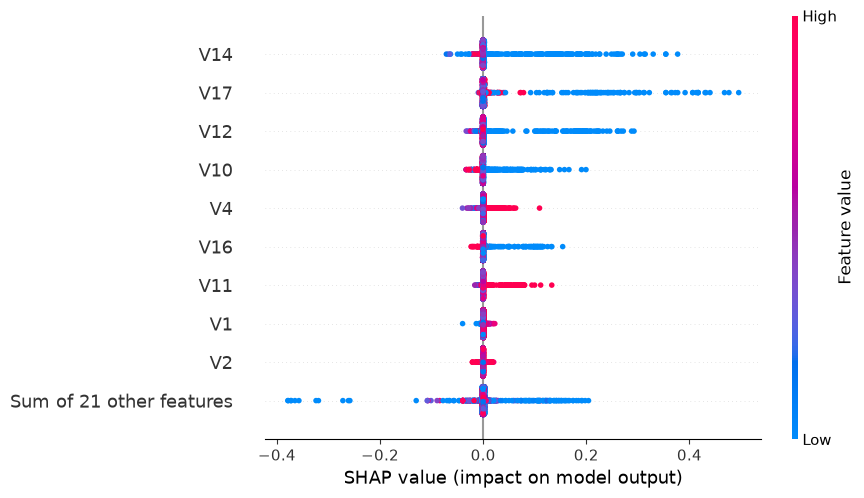

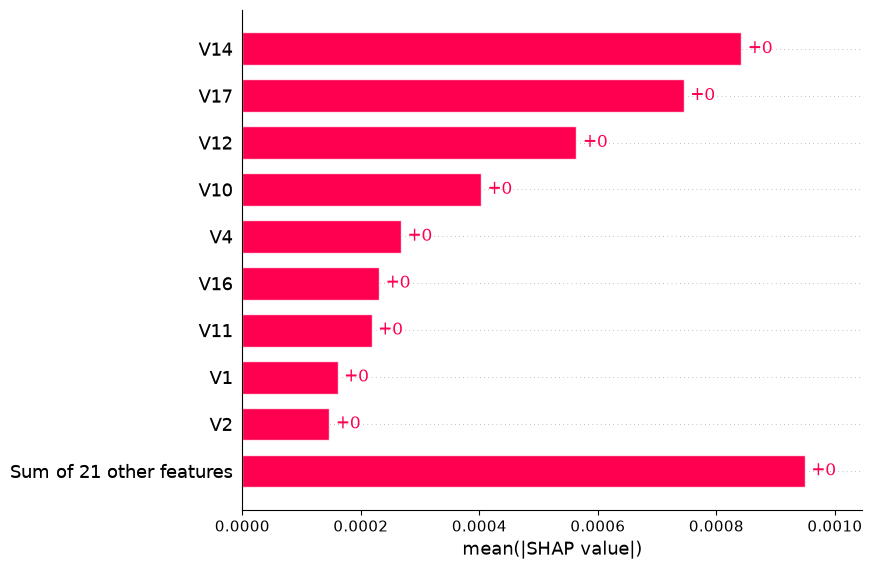

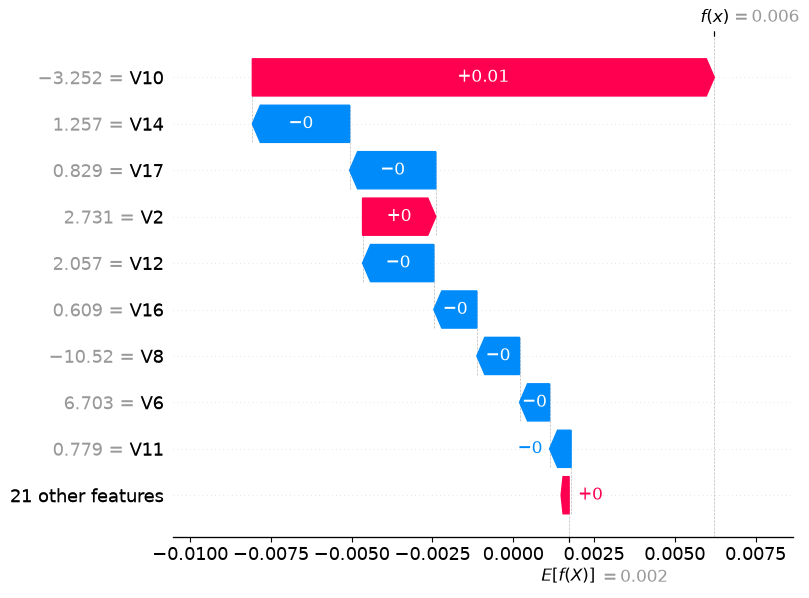

In [10]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

best_rf = RandomForestClassifier(
    n_estimators =200,
    max_depth = 10,
    min_samples_split = 2,
    min_samples_leaf = 1,
    random_state = 42
)
best_rf.fit(X_train,y_train)

explainer = shap.TreeExplainer(best_rf)


explainer = shap.TreeExplainer(best_rf)

shap_values = explainer(X_test)

# Global importance
shap.plots.beeswarm(shap_values[:, :, 1])

# Feature importance
shap.plots.bar(shap_values[:, :, 1])

# Single prediction explanation
sample_index = 10
shap.plots.waterfall(shap_values[sample_index, :, 1])